# 03 · Learning and bias

Two questions about the recognition models, read from the committed `evaluation/results.json` only. Nothing here touches raw data or model weights; `uv run ryuk evaluate learn` and `uv run ryuk evaluate bias` compute the numbers. The comparison and the breakdown follow the learning-and-bias decision (#10).

First, does anything learned on the frozen embeddings beat the best-photo rule, and which rule should each model run live? Then, at each model's single frozen threshold, whom does the system fail: TPIR, FPIR and misidentification per group of identities and per photo condition.

In [1]:
%matplotlib inline
import math
from pathlib import Path

from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

from ryuk.evaluation.figures import gap_distributions, group_fpir, learned_rules, learning_gains
from ryuk.evaluation.names import model_name
from ryuk.evaluation.results import Results
from ryuk.evaluation.tables import (
    METHOD_NAMES,
    bias_markdown,
    breakdown_name,
    fpir_ratio_markdown,
    learning_markdown,
    method_rates_table,
)
from ryuk.plotting import use_lab_style

use_lab_style()
# PNG at the style's 150 dpi keeps the committed notebook small; the figures are drawn with
# constrained layout, so the inline backend's tight bounding box would only pad them.
set_matplotlib_formats("png", bbox_inches=None)

here = Path.cwd().resolve()
root = next(p for p in (here, *here.parents) if (p / "evaluation" / "results.json").is_file())
results = Results.model_validate_json((root / "evaluation" / "results.json").read_bytes())
identification, learning, bias = results.identification, results.learning, results.bias
if identification is None:
    raise RuntimeError("no CelebA results: run `uv run ryuk evaluate celeba`")
if learning is None:
    raise RuntimeError("no learning results: run `uv run ryuk evaluate learn`")
if bias is None:
    raise RuntimeError("no bias breakdown: run `uv run ryuk evaluate bias`")
for name, provenance in (
    ("CelebA", identification.provenance),
    ("Learning", learning.provenance),
    ("Bias", bias.provenance),
):
    print(
        f"{name:9} commit {provenance.commit[:12]}{' (dirty)' if provenance.dirty else ''}, "
        f"{provenance.generated_at:%Y-%m-%d %H:%M} UTC, {provenance.machine}"
    )

CelebA    commit fb677d3223fb, 2026-09-25 21:46 UTC, macOS-27.0-arm64-arm-64bit (arm64)
Learning  commit dbc08c4e8065, 2026-09-29 20:19 UTC, macOS-27.0-arm64-arm-64bit (arm64)
Bias      commit 96d37c4eb414, 2026-09-29 20:22 UTC, macOS-27.0-arm64-arm-64bit (arm64)


## Learning on embeddings

Six methods score the same two draws as notebook 02, on every recognition model:

- **Scoring rules**, nothing fitted: *best photo*, the baseline, is the cosine to the candidate's best enrolled photo; *mean* is the cosine to the renormalised mean of the candidate's enrolled embeddings.
- **Classifiers** trained on the gallery's enrolled embeddings: kNN with inverse-distance voting, multinomial logistic regression and a linear SVM. Each goes open set by thresholding its top class's score; none has a class for strangers, since any source of unknown faces would leak test identities or be arbitrary.
- **The learned rule**: a logistic regression on two numbers about the best-photo top candidate, its match score and its gap to the runner-up, fitted per recognition model. It never sees the gallery, so it is gallery-agnostic.

Everything is fitted on the validation draw only, and the code refuses anything else. Each classifier's hyperparameter is chosen by training it on the validation gallery and scoring the validation probes, then frozen; on the test draw the classifier is retrained, with that value, on the test gallery, which is enrollment as it would be live. The learned rule is fitted on the validation probes with identity-grouped cross-fitting, and its cut-off comes from the out-of-fold output. Every method's threshold is frozen at FPIR 1% on the validation draw, and the test draw is scored once.

Methods are compared at the same operating point: TPIR at FPIR 1% read off each method's own test curve. A method beats best photo only if the 95% paired bootstrap interval of its TPIR gain lies wholly above zero; both methods are read in the same resamples of the same identities. A classifier needs retraining on every enrollment, removal and purge, so it never runs live whatever its gain. Of the methods that need no retraining and improve, the one with the largest gain runs live.

**Table 3 · Learning on embeddings (test draw)**

In [2]:
display(Markdown(learning_markdown(results)))

|  | SFace | ArcFace (CoreML) | FaceNet |
|:---------------------------|------------------------:|------------------------:|------------------------:|
| Best photo | 95.3 [94.3–96.1] | 98.5 [98.1–98.9] ★ | 84.5 [81.2–87.9] |
| Mean | 96.6 [95.7–97.3] ★ | 98.3 [97.9–98.7] | 88.4 [85.5–90.4] ★ |
| *Gain* | **+1.4 [+0.6, +2.0]** | −0.2 [−0.4, 0.0] | **+3.9 [+1.6, +5.8]** |
| kNN † | 91.3 [89.7–92.8] | 94.1 [92.4–95.8] | 76.4 [72.4–80.5] |
| *Gain* | −3.9 [−5.2, −2.7] | −4.3 [−5.9, −2.9] | −8.0 [−11.7, −4.1] |
| Logistic regression † | 96.5 [95.9–97.2] | 98.5 [98.2–98.9] | 88.8 [87.0–90.7] |
| *Gain* | **+1.3 [+0.7, +2.0]** | 0.0 [−0.1, +0.2] | **+4.3 [+1.5, +7.1]** |
| Linear SVM † | 95.7 [94.9–96.5] | 98.5 [98.1–98.9] | 83.7 [80.1–87.1] |
| *Gain* | +0.5 [−0.2, +1.3] | 0.0 [−0.1, +0.1] | −0.8 [−4.4, +2.9] |
| Learned rule | 95.4 [94.6–96.2] | 98.5 [98.1–98.8] | 85.8 [82.9–88.3] |
| *Gain* | +0.1 [−0.1, +0.5] | 0.0 [−0.1, 0.0] | +1.3 [−0.8, +3.6] |

CelebA test draw. TPIR at FPIR 1% is read off each method's own test curve, at the threshold that gives FPIR 1% on the test draw itself, so every method is compared at the same FPIR. At each method's threshold frozen on the validation draw, which is what the live monitor would run, test FPIR lands either side of 1%. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

*Gain*: the method's TPIR minus best photo's, in percentage points, with the 95% paired bootstrap interval of the difference: both methods are read in the same resamples of the same identities. **Bold**: the interval lies wholly above zero, a measurable improvement; anything else is no measurable improvement.

No method measurably improves on best photo for ArcFace (CoreML).

★ The rule each model runs live. SFace: The mean rule improves test TPIR at FPIR 1% on best-photo by +1.36 points (95% CI +0.61 to +1.96), the largest measurable gain of the methods that need no retraining. ArcFace (CoreML): No method that needs no retraining measurably improves test TPIR at FPIR 1% on best-photo: the mean rule -0.19 points (95% CI -0.39 to +0.01), the learned rule -0.01 points (95% CI -0.07 to +0.00). FaceNet: The mean rule improves test TPIR at FPIR 1% on best-photo by +3.95 points (95% CI +1.60 to +5.80), the largest measurable gain of the methods that need no retraining.

† Needs retraining whenever the watchlist changes, so never runs live, whatever its gain.

Hyperparameters chosen on the validation draw, each candidate trained on its gallery and scored on its probes, then frozen: kNN k = 5 (SFace), 15 (ArcFace (CoreML)), 15 (FaceNet), of 3, 5, 7, 9, 15; logistic regression C = 10 for every model, of 0.1, 1, 10, 100; linear SVM C = 1 for every model, of 0.01, 0.1, 1, 10. Each classifier is trained on its draw's own gallery.

The learned rule is a logistic regression on the top candidate's best-photo score and its gap to the runner-up, fitted on the validation draw's probes with 5-fold identity-grouped cross-fitting; its cut-off on P(match) comes from the out-of-fold output. Coefficients: SFace intercept −18.38, top score 34.93, gap 17.81; ArcFace (CoreML) intercept −12.64, top score 29.00, gap 7.46; FaceNet intercept −19.00, top score 27.63, gap 11.01.

**Figure 3 · Each method's TPIR gain over best photo.** The test TPIR gain at FPIR 1%, in percentage points, with its 95% paired bootstrap interval, a point per model. A filled marker and a heavy interval lie wholly above zero, a measurable improvement. Shaded rows need retraining whenever the watchlist changes and never run live.

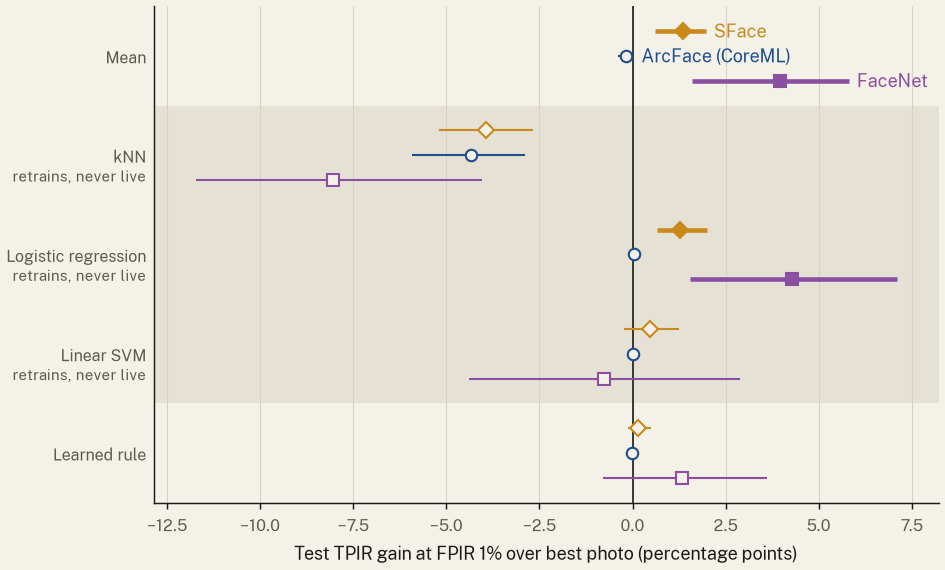

In [3]:
learning_gains(learning)

## Each method at its frozen threshold

Table 3 compares methods at the same test FPIR. The live monitor runs a method at its threshold frozen on the validation draw instead, where test FPIR lands either side of 1%. These are every method's test rates there, with rank-1; ★ marks the model's live rule and † a method that needs retraining.

In [4]:
for compared in learning.models:
    display(Markdown(f"**{model_name(compared.model)}**"))
    display(Markdown(method_rates_table(results, compared.model)))

**SFace**

| Method | Rank-1 | Frozen threshold | TPIR | FPIR | Misidentification |
|---|---:|---:|---:|---:|---:|
| Best photo | 98.0 [97.6–98.5] | 0.498 | 95.0 [94.2–95.8] | 0.91 [0.62–1.24] | 0.16 [0.05–0.31] |
| Mean ★ | 98.1 [97.7–98.5] | 0.494 | 96.2 [95.4–96.9] | 0.74 [0.48–1.03] | 0.15 [0.07–0.24] |
| kNN † | 97.9 [97.4–98.4] | 0.805 | 91.4 [89.9–92.9] | 1.11 [0.79–1.45] | 0.04 [0.00–0.09] |
| Logistic regression † | 98.2 [97.8–98.6] | 0.078 | 96.1 [95.4–96.7] | 0.64 [0.38–0.93] | 0.17 [0.07–0.31] |
| Linear SVM † | 98.1 [97.6–98.5] | -0.402 | 95.6 [94.8–96.3] | 0.88 [0.55–1.25] | 0.12 [0.04–0.24] |
| Learned rule | 98.0 [97.6–98.5] | 0.635 | 95.4 [94.6–96.1] | 0.98 [0.69–1.28] | 0.15 [0.04–0.29] |

**ArcFace (CoreML)**

| Method | Rank-1 | Frozen threshold | TPIR | FPIR | Misidentification |
|---|---:|---:|---:|---:|---:|
| Best photo ★ | 98.6 [98.3–99.0] | 0.342 | 98.5 [98.1–98.8] | 0.66 [0.40–0.94] | 0.13 [0.04–0.25] |
| Mean | 98.6 [98.2–98.9] | 0.326 | 98.3 [97.8–98.7] | 0.56 [0.32–0.83] | 0.12 [0.05–0.20] |
| kNN † | 97.9 [97.2–98.5] | 0.344 | 94.1 [92.4–95.8] | 0.79 [0.47–1.14] | 0.08 [0.03–0.15] |
| Logistic regression † | 98.8 [98.4–99.1] | 0.036 | 98.5 [98.1–98.8] | 0.47 [0.27–0.70] | 0.12 [0.05–0.20] |
| Linear SVM † | 98.7 [98.4–99.0] | -0.517 | 98.5 [98.1–98.9] | 0.69 [0.43–0.97] | 0.15 [0.07–0.24] |
| Learned rule | 98.6 [98.3–99.0] | 0.117 | 98.5 [98.1–98.8] | 0.69 [0.42–0.97] | 0.13 [0.04–0.25] |

**FaceNet**

| Method | Rank-1 | Frozen threshold | TPIR | FPIR | Misidentification |
|---|---:|---:|---:|---:|---:|
| Best photo | 96.6 [95.9–97.2] | 0.709 | 85.1 [83.5–86.7] | 1.20 [0.74–1.73] | 0.39 [0.24–0.55] |
| Mean ★ | 97.0 [96.3–97.5] | 0.691 | 88.4 [87.0–89.7] | 0.96 [0.59–1.37] | 0.29 [0.16–0.45] |
| kNN † | 95.6 [94.7–96.3] | 0.370 | 78.1 [75.7–80.5] | 1.23 [0.62–1.94] | 0.08 [0.03–0.15] |
| Logistic regression † | 97.3 [96.7–97.8] | 0.287 | 87.1 [85.7–88.5] | 0.61 [0.37–0.91] | 0.15 [0.05–0.25] |
| Linear SVM † | 97.0 [96.4–97.6] | -0.111 | 83.2 [81.4–84.9] | 0.86 [0.46–1.33] | 0.07 [0.01–0.13] |
| Learned rule | 96.6 [95.9–97.2] | 0.883 | 86.2 [84.7–87.8] | 1.03 [0.59–1.55] | 0.19 [0.09–0.31] |

## The chosen hyperparameters

Each classifier's candidate values were fixed before the test draw was scored, and the grid was not widened after. A value chosen at the edge of its grid is marked: a better one may lie beyond it.

In [5]:
rows = ["| Model | Method | Chosen | Candidates | At the edge |", "|---|---|---:|---|:---:|"]
for compared in learning.models:
    for result in compared.methods:
        chosen = result.hyperparameter
        if chosen is None:
            continue
        edge = chosen.value in (min(chosen.candidates), max(chosen.candidates))
        rows.append(
            f"| {model_name(compared.model)} | {METHOD_NAMES[result.method]} "
            f"| {chosen.name} = {chosen.value:g} "
            f"| {', '.join(f'{value:g}' for value in chosen.candidates)} | {'✓' if edge else ''} |"
        )
display(Markdown("\n".join(rows)))

| Model | Method | Chosen | Candidates | At the edge |
|---|---|---:|---|:---:|
| SFace | kNN | k = 5 | 3, 5, 7, 9, 15 |  |
| SFace | Logistic regression | C = 10 | 0.1, 1, 10, 100 |  |
| SFace | Linear SVM | C = 1 | 0.01, 0.1, 1, 10 |  |
| ArcFace (CoreML) | kNN | k = 15 | 3, 5, 7, 9, 15 | ✓ |
| ArcFace (CoreML) | Logistic regression | C = 10 | 0.1, 1, 10, 100 |  |
| ArcFace (CoreML) | Linear SVM | C = 1 | 0.01, 0.1, 1, 10 |  |
| FaceNet | kNN | k = 15 | 3, 5, 7, 9, 15 | ✓ |
| FaceNet | Logistic regression | C = 10 | 0.1, 1, 10, 100 |  |
| FaceNet | Linear SVM | C = 1 | 0.01, 0.1, 1, 10 |  |

## The learned rule

For a probe whose best-photo top candidate scores *s* and whose runner-up, the second-best identity, scores *r*, the learned rule's output is

P(match) = 1 / (1 + exp(−(intercept + a·s + b·(s − r))))

and a probe is a match when that is at or above the rule's frozen cut-off. The number of enrolled photos is deliberately not an input: it is always 5 in evaluation but varies live. Where the output equals the cut-off, the boundary is a straight line in (top score, gap).

In [6]:
rows = [
    "| Model | Intercept | Top score (a) | Gap (b) | Cut-off | Top score needed at gap 0 "
    "| Best photo's threshold |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
for compared in learning.models:
    rule = compared.learned_rule
    cut_off = compared.method("learned").threshold
    logit = math.log(cut_off / (1 - cut_off))
    rows.append(
        f"| {model_name(compared.model)} | {rule.intercept:.2f} | {rule.top_score:.2f} "
        f"| {rule.gap:.2f} | {cut_off:.3f} | {(logit - rule.intercept) / rule.top_score:.3f} "
        f"| {compared.method('best-photo').threshold:.3f} |"
    )
display(Markdown("\n".join(rows)))

| Model | Intercept | Top score (a) | Gap (b) | Cut-off | Top score needed at gap 0 | Best photo's threshold |
|---|---:|---:|---:|---:|---:|---:|
| SFace | -18.38 | 34.93 | 17.81 | 0.635 | 0.542 | 0.498 |
| ArcFace (CoreML) | -12.64 | 29.00 | 7.46 | 0.117 | 0.366 | 0.342 |
| FaceNet | -19.00 | 27.63 | 11.01 | 0.883 | 0.761 | 0.709 |

**Figure 4 · The learned rule's decision boundary.** A sample of validation probes as their best-photo top score against the gap to the runner-up, a panel per model. The solid line is the learned rule's boundary at its frozen cut-off, a match above and right of it; the dashed line is best photo's frozen threshold, which ignores the gap. Every probe whose top candidate is wrong is kept, so the kinds are not in proportion.

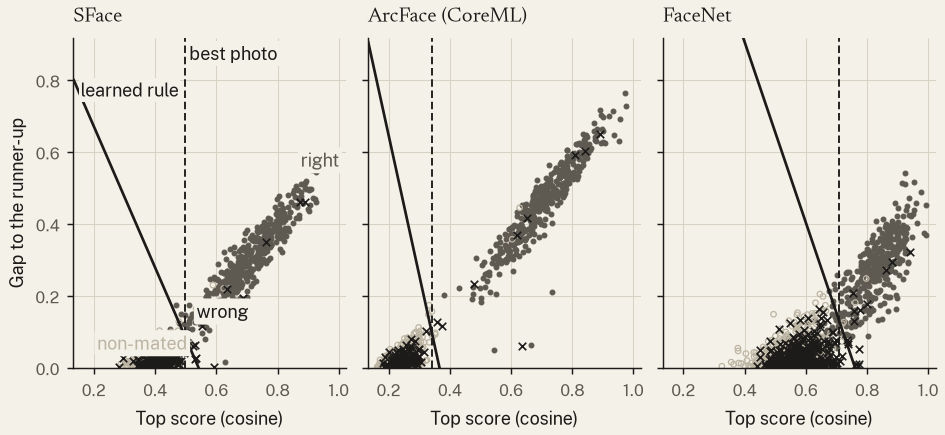

In [7]:
learned_rules(learning)

## The gap to the runner-up

A small gap between the top candidate and the runner-up was once proposed as a third, "ambiguous" outcome (#11). The decision (#10) keeps two outcomes, match and no match, and lets the gap count only through the learned rule. Figure 5 and the table under it show the gap on the test draw for mated probes whose top candidate is right, mated probes whose top candidate is wrong, and non-mated probes.

**Figure 5 · The gap to the runner-up on the test draw.** How far the best-photo top candidate scores above the runner-up, as a density per kind of probe, a panel per model. The axis stops where 99% of every kind's probes have been counted.

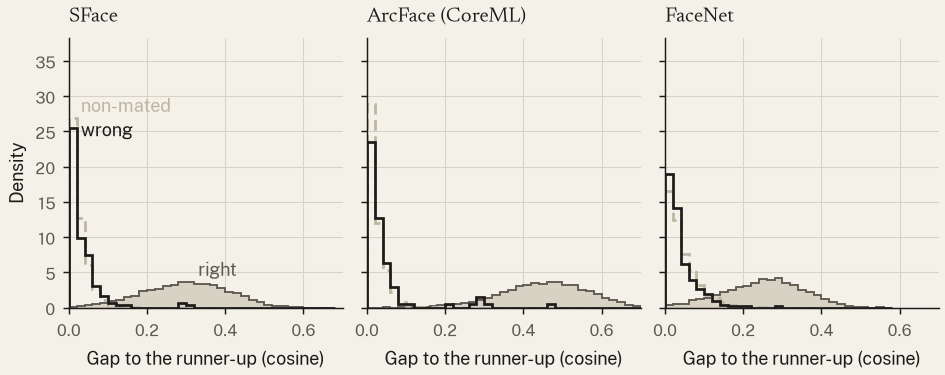

In [8]:
gap_distributions(learning)

In [9]:
def share_below(counts: list[int], bins: int) -> float:
    """The share of a kind's probes in the first `bins` bins of the gap histogram."""
    return sum(counts[:bins]) / sum(counts)


small = 2
rows = [
    "| Model | Kind | Probes | Gap under "
    f"{learning.models[0].gaps.edges[small]:.2f} | Share of wrong rejected by best photo |",
    "|---|---|---:|---:|---:|",
]
for compared in learning.models:
    gaps = compared.gaps
    if gaps.edges[small] != learning.models[0].gaps.edges[small]:
        raise RuntimeError("the models' gap histograms have different bins")
    baseline = compared.method("best-photo").test
    wrong_first = 1 - baseline.rank_1.value
    rejected = 1 - baseline.at_threshold.misidentification.value / wrong_first
    for kind, counts in (
        ("right", gaps.right),
        ("wrong", gaps.wrong),
        ("non-mated", gaps.non_mated),
    ):
        rows.append(
            f"| {model_name(compared.model)} | {kind} | {sum(counts):,} "
            f"| {share_below(counts, small):.1%} | {f'{rejected:.1%}' if kind == 'wrong' else ''} |"
        )
display(Markdown("\n".join(rows)))

| Model | Kind | Probes | Gap under 0.04 | Share of wrong rejected by best photo |
|---|---|---:|---:|---:|
| SFace | right | 7,353 | 0.9% |  |
| SFace | wrong | 147 | 70.7% | 91.8% |
| SFace | non-mated | 4,072 | 79.2% |  |
| ArcFace (CoreML) | right | 7,398 | 0.1% |  |
| ArcFace (CoreML) | wrong | 102 | 72.5% | 90.2% |
| ArcFace (CoreML) | non-mated | 4,072 | 81.9% |  |
| FaceNet | right | 7,242 | 1.7% |  |
| FaceNet | wrong | 258 | 66.3% | 88.8% |
| FaceNet | non-mated | 4,072 | 58.0% |  |

Wrong top candidates sit close to their runner-up, much as non-mated probes' top candidates do, while right ones stand well clear. But wrong top candidates also score low, so best photo's threshold already turns most of them away (last column): what is left for the gap to catch is the misidentification rate of Table 2.

## The rule each model runs live

Each model's live rule and why, and the thresholds block the service reads. The first active model rule judges each model under its live rule, at that rule's frozen threshold.

In [10]:
for compared in learning.models:
    print(
        f"{model_name(compared.model)}: {METHOD_NAMES[compared.live_rule]}. {compared.live_reason}"
    )
rows = ["| Model | Rule | Threshold | Target FPIR |", "|---|---|---:|---:|"]
for t in results.thresholds:
    rows.append(f"| {model_name(t.model)} | {t.rule} | {t.threshold:.4f} | {t.target_fpir:.0%} |")
display(Markdown("\n".join(rows)))
active = results.first_active_model
if active is None:
    raise RuntimeError("no first active model: run `uv run ryuk evaluate celeba`")
chosen = "none" if active.model is None else model_name(active.model)
print(f"First active model: {chosen}. {active.reason}")

SFace: Mean. The mean rule improves test TPIR at FPIR 1% on best-photo by +1.36 points (95% CI +0.61 to +1.96), the largest measurable gain of the methods that need no retraining.
ArcFace (CoreML): Best photo. No method that needs no retraining measurably improves test TPIR at FPIR 1% on best-photo: the mean rule -0.19 points (95% CI -0.39 to +0.01), the learned rule -0.01 points (95% CI -0.07 to +0.00).
FaceNet: Mean. The mean rule improves test TPIR at FPIR 1% on best-photo by +3.95 points (95% CI +1.60 to +5.80), the largest measurable gain of the methods that need no retraining.


| Model | Rule | Threshold | Target FPIR |
|---|---|---:|---:|
| SFace | mean | 0.4943 | 1% |
| ArcFace (CoreML) | best-photo | 0.3417 | 1% |
| FaceNet | mean | 0.6911 | 1% |

First active model: ArcFace (CoreML). ArcFace (CoreML) has the highest test TPIR at its frozen threshold (98.47%) of the 3 eligible models, and no other's interval overlaps it.


## Bias breakdown

Per-group rates on the test draw at each model's single frozen threshold: no group gets its own, since per-group thresholds are a fairness intervention, not a measurement. Each model is broken down under best photo and, where it differs, under its live rule.

- **Identity groups.** Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% agree, as in the EDA; an identity with no such majority is left out of that attribute and counted. The four Male and Young cells are indicative only.
- **Photo conditions.** Eyeglasses, Wearing_Hat and Blurry go by each probe's own label.
- TPIR and misidentification are over the mated probes of a group's gallery identities, FPIR over the non-mated probes of its held-out identities. A rate resting on fewer than 30 identities is reported as too few to estimate, never dropped.
- The gallery was drawn at random with the committed seed, not stratified, so its identity counts are its composition.

CelebA has no skin-tone or race label, so neither can be broken down here. Pale_Skin marks too few gallery-eligible identities to form a group, and Heavy_Makeup is left out as a near-proxy for not male. YuNet also finds faces less often for majority-male and not-young identities (notebook 01), so every rate below is over the faces it found.

**Table 4 · The bias breakdown, one table per model and rule (test draw)**

In [11]:
for breakdown in bias.models:
    display(Markdown(f"### {breakdown_name(breakdown)}"))
    display(Markdown(bias_markdown(results, breakdown.model, breakdown.rule)))

### SFace

| Group | Gallery identities | Mated probes | TPIR | Misidentification | Held-out identities | Non-mated probes | FPIR |
|:---|---:|---:|---:|---:|---:|---:|---:|
| *Male* |  |  |  |  |  |  |  |
| Male | 177 | 2,655 | 97.8 [96.9–98.6] | 0.00 [0.00–0.00] | 240 | 1,956 | 0.36 [0.10–0.66] |
| Not male | 323 | 4,845 | 93.5 [92.4–94.5] | 0.25 [0.08–0.47] | 253 | 2,095 | 1.38 [0.85–1.96] |
| *Young* |  |  |  |  |  |  |  |
| Young | 379 | 5,685 | 95.0 [94.1–95.9] | 0.21 [0.07–0.40] | 308 | 2,598 | 1.04 [0.66–1.47] |
| Not young | 82 | 1,230 | 96.3 [94.6–97.7] | 0.00 [0.00–0.00] | 164 | 1,248 | 0.32 [0.00–0.75] |
| *Male and young* | *indicative* |  |  |  |  |  |  |
| Male, young | 112 | 1,680 | 98.0 [96.7–98.9] | 0.00 [0.00–0.00] | 123 | 1,056 | 0.57 [0.19–1.05] |
| Male, not young | 53 | 795 | 97.5 [95.7–98.9] | 0.00 [0.00–0.00] | 111 | 845 | 0.00 [0.00–0.00] |
| Not male, young | 267 | 4,005 | 93.7 [92.6–94.9] | 0.30 [0.10–0.55] | 182 | 1,535 | 1.30 [0.73–1.93] |
| Not male, not young | 29 | 435 | too few | too few | 51 | 399 | 1.00 [0.00–2.26] |
| *Eyeglasses* | *per photo* |  |  |  |  |  |  |
| Eyeglasses | 150 | 396 | 92.2 [88.7–95.0] | 0.00 [0.00–0.00] | 121 | 348 | 0.57 [0.00–1.50] |
| No eyeglasses | 496 | 7,104 | 95.2 [94.3–95.9] | 0.17 [0.06–0.33] | 484 | 3,724 | 0.94 [0.63–1.28] |
| *Wearing a hat* | *per photo* |  |  |  |  |  |  |
| Hat | 127 | 276 | 86.6 [81.1–90.9] | 0.36 [0.00–1.21] | 96 | 208 | 0.48 [0.00–1.59] |
| No hat | 500 | 7,224 | 95.3 [94.5–96.1] | 0.15 [0.04–0.30] | 499 | 3,864 | 0.93 [0.61–1.29] |
| *Blurry* | *per photo* |  |  |  |  |  |  |
| Blurry | 169 | 303 | 81.2 [76.2–85.6] | 0.66 [0.00–1.66] | 165 | 253 | 1.19 [0.00–2.80] |
| Not blurry | 500 | 7,197 | 95.6 [94.8–96.3] | 0.14 [0.04–0.29] | 500 | 3,819 | 0.89 [0.59–1.23] |

CelebA test draw, SFace under best photo at its single threshold, 0.498, frozen on the validation draw: no group has its own. TPIR and misidentification are over the mated probes of each group's gallery identities, FPIR over the non-mated probes of its held-out identities. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% of them agree. Identities with no such majority are left out: Male 0 gallery and 7 held-out, Young 39 gallery and 28 held-out, Male and young 39 gallery and 33 held-out.

Eyeglasses, Wearing a hat and Blurry go by each probe's own label, so one identity's probes can fall in both groups; its identities are those with a probe in the group.

Too few: fewer than 30 identities stand behind the rate, so it is not estimated; the group is still reported with its counts.

The gallery was drawn at random, not stratified; its identity counts are its composition.

Where the dependence-adjusted Wilson interval (Fogliato et al.) differs meaningfully from the bootstrap for a rate within 1% of 0 or 100%, it is: Male misidentification [0.00–2.12]; Not young misidentification [0.00–4.48]; Not young FPIR [0.10–0.98]; Male, young misidentification [0.00–3.32]; Male, not young misidentification [0.00–6.76]; Male, not young FPIR [0.00–3.35]; Eyeglasses misidentification [0.00–2.50]; Eyeglasses FPIR [0.16–2.07]; Hat misidentification [0.06–2.04]; Hat FPIR [0.08–2.67]; Blurry misidentification [0.18–2.37].

### SFace, mean

| Group | Gallery identities | Mated probes | TPIR | Misidentification | Held-out identities | Non-mated probes | FPIR |
|:---|---:|---:|---:|---:|---:|---:|---:|
| *Male* |  |  |  |  |  |  |  |
| Male | 177 | 2,655 | 98.2 [97.2–99.0] | 0.00 [0.00–0.00] | 240 | 1,956 | 0.00 [0.00–0.00] |
| Not male | 323 | 4,845 | 95.1 [94.0–96.0] | 0.23 [0.10–0.37] | 253 | 2,095 | 1.38 [0.86–1.92] |
| *Young* |  |  |  |  |  |  |  |
| Young | 379 | 5,685 | 96.3 [95.5–97.1] | 0.19 [0.09–0.30] | 308 | 2,598 | 0.81 [0.45–1.17] |
| Not young | 82 | 1,230 | 96.4 [94.8–97.7] | 0.00 [0.00–0.00] | 164 | 1,248 | 0.48 [0.08–0.96] |
| *Male and young* | *indicative* |  |  |  |  |  |  |
| Male, young | 112 | 1,680 | 98.2 [96.7–99.4] | 0.00 [0.00–0.00] | 123 | 1,056 | 0.00 [0.00–0.00] |
| Male, not young | 53 | 795 | 98.4 [97.2–99.4] | 0.00 [0.00–0.00] | 111 | 845 | 0.00 [0.00–0.00] |
| Not male, young | 267 | 4,005 | 95.6 [94.5–96.5] | 0.27 [0.12–0.42] | 182 | 1,535 | 1.30 [0.75–1.92] |
| Not male, not young | 29 | 435 | too few | too few | 51 | 399 | 1.50 [0.47–2.92] |
| *Eyeglasses* | *per photo* |  |  |  |  |  |  |
| Eyeglasses | 150 | 396 | 94.9 [92.2–97.1] | 0.00 [0.00–0.00] | 121 | 348 | 0.29 [0.00–0.96] |
| No eyeglasses | 496 | 7,104 | 96.3 [95.4–96.9] | 0.15 [0.07–0.25] | 484 | 3,724 | 0.78 [0.50–1.09] |
| *Wearing a hat* | *per photo* |  |  |  |  |  |  |
| Hat | 127 | 276 | 89.9 [85.4–93.5] | 0.00 [0.00–0.00] | 96 | 208 | 0.00 [0.00–0.00] |
| No hat | 500 | 7,224 | 96.4 [95.7–97.1] | 0.15 [0.07–0.25] | 499 | 3,864 | 0.78 [0.49–1.08] |
| *Blurry* | *per photo* |  |  |  |  |  |  |
| Blurry | 169 | 303 | 87.5 [83.5–91.0] | 0.33 [0.00–1.07] | 165 | 253 | 1.19 [0.00–2.73] |
| Not blurry | 500 | 7,197 | 96.6 [95.8–97.2] | 0.14 [0.06–0.24] | 500 | 3,819 | 0.71 [0.44–1.00] |

CelebA test draw, SFace under mean at its single threshold, 0.494, frozen on the validation draw: no group has its own. TPIR and misidentification are over the mated probes of each group's gallery identities, FPIR over the non-mated probes of its held-out identities. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% of them agree. Identities with no such majority are left out: Male 0 gallery and 7 held-out, Young 39 gallery and 28 held-out, Male and young 39 gallery and 33 held-out.

Eyeglasses, Wearing a hat and Blurry go by each probe's own label, so one identity's probes can fall in both groups; its identities are those with a probe in the group.

Too few: fewer than 30 identities stand behind the rate, so it is not estimated; the group is still reported with its counts.

The gallery was drawn at random, not stratified; its identity counts are its composition.

Where the dependence-adjusted Wilson interval (Fogliato et al.) differs meaningfully from the bootstrap for a rate within 1% of 0 or 100%, it is: Male misidentification [0.00–2.12]; Male FPIR [0.00–1.58]; Not young misidentification [0.00–4.48]; Male, young misidentification [0.00–3.32]; Male, young FPIR [0.00–3.03]; Male, not young misidentification [0.00–6.76]; Male, not young FPIR [0.00–3.35]; Eyeglasses misidentification [0.00–2.50]; Eyeglasses FPIR [0.05–1.62]; Hat misidentification [0.00–2.94]; Hat FPIR [0.00–3.85]; Blurry misidentification [0.06–1.85].

### ArcFace (CoreML)

| Group | Gallery identities | Mated probes | TPIR | Misidentification | Held-out identities | Non-mated probes | FPIR |
|:---|---:|---:|---:|---:|---:|---:|---:|
| *Male* |  |  |  |  |  |  |  |
| Male | 177 | 2,655 | 99.4 [99.0–99.8] | 0.00 [0.00–0.00] | 240 | 1,956 | 0.26 [0.05–0.50] |
| Not male | 323 | 4,845 | 97.9 [97.4–98.4] | 0.21 [0.06–0.39] | 253 | 2,095 | 1.05 [0.62–1.54] |
| *Young* |  |  |  |  |  |  |  |
| Young | 379 | 5,685 | 98.5 [98.1–98.9] | 0.18 [0.05–0.33] | 308 | 2,598 | 0.85 [0.53–1.22] |
| Not young | 82 | 1,230 | 98.7 [97.6–99.5] | 0.00 [0.00–0.00] | 164 | 1,248 | 0.32 [0.00–0.76] |
| *Male and young* | *indicative* |  |  |  |  |  |  |
| Male, young | 112 | 1,680 | 99.3 [98.6–99.9] | 0.00 [0.00–0.00] | 123 | 1,056 | 0.47 [0.09–0.88] |
| Male, not young | 53 | 795 | 99.7 [99.4–100.0] | 0.00 [0.00–0.00] | 111 | 845 | 0.00 [0.00–0.00] |
| Not male, young | 267 | 4,005 | 98.2 [97.6–98.7] | 0.25 [0.07–0.47] | 182 | 1,535 | 1.11 [0.60–1.71] |
| Not male, not young | 29 | 435 | too few | too few | 51 | 399 | 1.00 [0.00–2.50] |
| *Eyeglasses* | *per photo* |  |  |  |  |  |  |
| Eyeglasses | 150 | 396 | 99.2 [98.3–100.0] | 0.00 [0.00–0.00] | 121 | 348 | 0.29 [0.00–0.99] |
| No eyeglasses | 496 | 7,104 | 98.4 [98.0–98.8] | 0.14 [0.04–0.27] | 484 | 3,724 | 0.70 [0.44–0.98] |
| *Wearing a hat* | *per photo* |  |  |  |  |  |  |
| Hat | 127 | 276 | 97.8 [95.7–99.4] | 0.00 [0.00–0.00] | 96 | 208 | 0.48 [0.00–1.62] |
| No hat | 500 | 7,224 | 98.5 [98.1–98.9] | 0.14 [0.04–0.26] | 499 | 3,864 | 0.67 [0.42–0.97] |
| *Blurry* | *per photo* |  |  |  |  |  |  |
| Blurry | 169 | 303 | 96.4 [93.9–98.6] | 0.33 [0.00–1.07] | 165 | 253 | 0.79 [0.00–2.02] |
| Not blurry | 500 | 7,197 | 98.6 [98.2–98.9] | 0.13 [0.04–0.24] | 500 | 3,819 | 0.65 [0.41–0.95] |

CelebA test draw, ArcFace (CoreML) under best photo at its single threshold, 0.342, frozen on the validation draw: no group has its own. TPIR and misidentification are over the mated probes of each group's gallery identities, FPIR over the non-mated probes of its held-out identities. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% of them agree. Identities with no such majority are left out: Male 0 gallery and 7 held-out, Young 39 gallery and 28 held-out, Male and young 39 gallery and 33 held-out.

Eyeglasses, Wearing a hat and Blurry go by each probe's own label, so one identity's probes can fall in both groups; its identities are those with a probe in the group.

Too few: fewer than 30 identities stand behind the rate, so it is not estimated; the group is still reported with its counts.

The gallery was drawn at random, not stratified; its identity counts are its composition.

Where the dependence-adjusted Wilson interval (Fogliato et al.) differs meaningfully from the bootstrap for a rate within 1% of 0 or 100%, it is: Male misidentification [0.00–2.12]; Not young misidentification [0.00–4.48]; Not young FPIR [0.10–0.99]; Male, young misidentification [0.00–3.32]; Male, not young TPIR [99.1–99.9]; Male, not young misidentification [0.00–6.76]; Male, not young FPIR [0.00–3.35]; Eyeglasses misidentification [0.00–2.50]; Eyeglasses FPIR [0.05–1.62]; Hat misidentification [0.00–2.94]; Hat FPIR [0.08–2.70]; Blurry misidentification [0.06–1.85]; Blurry FPIR [0.22–2.84].

### FaceNet

| Group | Gallery identities | Mated probes | TPIR | Misidentification | Held-out identities | Non-mated probes | FPIR |
|:---|---:|---:|---:|---:|---:|---:|---:|
| *Male* |  |  |  |  |  |  |  |
| Male | 177 | 2,655 | 91.5 [89.6–93.2] | 0.11 [0.00–0.30] | 240 | 1,956 | 0.92 [0.35–1.62] |
| Not male | 323 | 4,845 | 81.6 [79.4–83.7] | 0.54 [0.33–0.76] | 253 | 2,095 | 1.48 [0.81–2.26] |
| *Young* |  |  |  |  |  |  |  |
| Young | 379 | 5,685 | 85.4 [83.6–87.1] | 0.46 [0.26–0.67] | 308 | 2,598 | 1.42 [0.83–2.08] |
| Not young | 82 | 1,230 | 89.1 [85.9–92.1] | 0.16 [0.00–0.49] | 164 | 1,248 | 0.96 [0.23–1.86] |
| *Male and young* | *indicative* |  |  |  |  |  |  |
| Male, young | 112 | 1,680 | 92.3 [90.1–94.2] | 0.06 [0.00–0.18] | 123 | 1,056 | 0.57 [0.09–1.22] |
| Male, not young | 53 | 795 | 90.9 [86.9–94.3] | 0.25 [0.00–0.75] | 111 | 845 | 1.42 [0.35–2.91] |
| Not male, young | 267 | 4,005 | 82.5 [80.2–84.8] | 0.62 [0.37–0.92] | 182 | 1,535 | 2.02 [1.09–3.05] |
| Not male, not young | 29 | 435 | too few | too few | 51 | 399 | 0.00 [0.00–0.00] |
| *Eyeglasses* | *per photo* |  |  |  |  |  |  |
| Eyeglasses | 150 | 396 | 76.3 [69.0–82.0] | 0.51 [0.00–1.37] | 121 | 348 | 1.15 [0.27–2.54] |
| No eyeglasses | 496 | 7,104 | 85.6 [84.1–87.1] | 0.38 [0.23–0.55] | 484 | 3,724 | 1.21 [0.72–1.76] |
| *Wearing a hat* | *per photo* |  |  |  |  |  |  |
| Hat | 127 | 276 | 74.3 [65.9–81.3] | 0.00 [0.00–0.00] | 96 | 208 | 0.48 [0.00–1.55] |
| No hat | 500 | 7,224 | 85.5 [83.9–87.1] | 0.40 [0.24–0.58] | 499 | 3,864 | 1.24 [0.75–1.79] |
| *Blurry* | *per photo* |  |  |  |  |  |  |
| Blurry | 169 | 303 | 60.4 [54.1–66.3] | 0.66 [0.00–1.66] | 165 | 253 | 2.77 [0.77–5.42] |
| Not blurry | 500 | 7,197 | 86.2 [84.7–87.6] | 0.38 [0.23–0.55] | 500 | 3,819 | 1.10 [0.68–1.62] |

CelebA test draw, FaceNet under best photo at its single threshold, 0.709, frozen on the validation draw: no group has its own. TPIR and misidentification are over the mated probes of each group's gallery identities, FPIR over the non-mated probes of its held-out identities. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% of them agree. Identities with no such majority are left out: Male 0 gallery and 7 held-out, Young 39 gallery and 28 held-out, Male and young 39 gallery and 33 held-out.

Eyeglasses, Wearing a hat and Blurry go by each probe's own label, so one identity's probes can fall in both groups; its identities are those with a probe in the group.

Too few: fewer than 30 identities stand behind the rate, so it is not estimated; the group is still reported with its counts.

The gallery was drawn at random, not stratified; its identity counts are its composition.

Where the dependence-adjusted Wilson interval (Fogliato et al.) differs meaningfully from the bootstrap for a rate within 1% of 0 or 100%, it is: Male misidentification [0.03–0.43]; Not young misidentification [0.03–0.91]; Male, young misidentification [0.01–0.34]; Male, not young misidentification [0.04–1.40]; Not male, not young FPIR [0.00–7.00]; Eyeglasses misidentification [0.14–1.84]; Hat misidentification [0.00–2.94]; Hat FPIR [0.08–2.68]; Blurry misidentification [0.18–2.37].

### FaceNet, mean

| Group | Gallery identities | Mated probes | TPIR | Misidentification | Held-out identities | Non-mated probes | FPIR |
|:---|---:|---:|---:|---:|---:|---:|---:|
| *Male* |  |  |  |  |  |  |  |
| Male | 177 | 2,655 | 93.1 [91.4–94.5] | 0.08 [0.00–0.23] | 240 | 1,956 | 0.72 [0.29–1.20] |
| Not male | 323 | 4,845 | 85.8 [83.9–87.6] | 0.41 [0.23–0.64] | 253 | 2,095 | 1.19 [0.61–1.88] |
| *Young* |  |  |  |  |  |  |  |
| Young | 379 | 5,685 | 88.9 [87.4–90.4] | 0.30 [0.14–0.49] | 308 | 2,598 | 1.19 [0.69–1.76] |
| Not young | 82 | 1,230 | 90.2 [87.1–93.0] | 0.24 [0.00–0.65] | 164 | 1,248 | 0.64 [0.16–1.25] |
| *Male and young* | *indicative* |  |  |  |  |  |  |
| Male, young | 112 | 1,680 | 93.9 [91.8–95.7] | 0.00 [0.00–0.00] | 123 | 1,056 | 0.57 [0.10–1.17] |
| Male, not young | 53 | 795 | 92.6 [89.1–95.7] | 0.25 [0.00–0.75] | 111 | 845 | 0.95 [0.23–1.90] |
| Not male, young | 267 | 4,005 | 86.8 [84.9–88.9] | 0.42 [0.20–0.67] | 182 | 1,535 | 1.63 [0.83–2.56] |
| Not male, not young | 29 | 435 | too few | too few | 51 | 399 | 0.00 [0.00–0.00] |
| *Eyeglasses* | *per photo* |  |  |  |  |  |  |
| Eyeglasses | 150 | 396 | 77.8 [71.2–83.3] | 0.00 [0.00–0.00] | 121 | 348 | 0.29 [0.00–0.95] |
| No eyeglasses | 496 | 7,104 | 88.9 [87.5–90.3] | 0.31 [0.18–0.48] | 484 | 3,724 | 1.02 [0.62–1.46] |
| *Wearing a hat* | *per photo* |  |  |  |  |  |  |
| Hat | 127 | 276 | 76.8 [68.6–83.4] | 0.72 [0.00–2.01] | 96 | 208 | 0.48 [0.00–1.55] |
| No hat | 500 | 7,224 | 88.8 [87.4–90.2] | 0.28 [0.15–0.43] | 499 | 3,864 | 0.98 [0.59–1.41] |
| *Blurry* | *per photo* |  |  |  |  |  |  |
| Blurry | 169 | 303 | 70.0 [64.3–75.4] | 0.66 [0.00–1.66] | 165 | 253 | 1.58 [0.37–3.31] |
| Not blurry | 500 | 7,197 | 89.1 [87.8–90.4] | 0.28 [0.14–0.43] | 500 | 3,819 | 0.92 [0.55–1.33] |

CelebA test draw, FaceNet under mean at its single threshold, 0.691, frozen on the validation draw: no group has its own. TPIR and misidentification are over the mated probes of each group's gallery identities, FPIR over the non-mated probes of its held-out identities. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples).

Male and Young go by each identity's majority label over all its images in the split, usable or not, where at least 80% of them agree. Identities with no such majority are left out: Male 0 gallery and 7 held-out, Young 39 gallery and 28 held-out, Male and young 39 gallery and 33 held-out.

Eyeglasses, Wearing a hat and Blurry go by each probe's own label, so one identity's probes can fall in both groups; its identities are those with a probe in the group.

Too few: fewer than 30 identities stand behind the rate, so it is not estimated; the group is still reported with its counts.

The gallery was drawn at random, not stratified; its identity counts are its composition.

Where the dependence-adjusted Wilson interval (Fogliato et al.) differs meaningfully from the bootstrap for a rate within 1% of 0 or 100%, it is: Male misidentification [0.01–0.42]; Not young misidentification [0.06–0.93]; Male, young misidentification [0.00–3.32]; Male, not young misidentification [0.04–1.40]; Not male, not young FPIR [0.00–7.00]; Eyeglasses misidentification [0.00–2.50]; Eyeglasses FPIR [0.05–1.61]; Hat misidentification [0.20–2.65]; Hat FPIR [0.08–2.68]; Blurry misidentification [0.18–2.37].

**Table 5 · Worst-to-best FPIR ratio (test draw)**

In [12]:
display(Markdown(fpir_ratio_markdown(results)))

|  | SFace | SFace, mean | ArcFace (CoreML) | FaceNet | FaceNet, mean |
|:------------------------------------|--------------:|--------------:|--------------:|--------------:|--------------:|
| Male | 3.87× | — | 4.11× | 1.61× | 1.67× |
| Young | 3.24× | 1.68× | 2.64× | 1.48× | 1.86× |
| Male and young (indicative) | — | — | — | — | — |
| Eyeglasses | 1.64× | 2.71× | 2.43× | 1.05× | 3.55× |
| Wearing a hat | 1.94× | — | 1.40× | 2.58× | 2.05× |
| Blurry | 1.33× | 1.68× | 1.21× | 2.52× | 1.73× |

The highest group FPIR over the lowest, per attribute, on the CelebA test draw at each model's single frozen threshold: under best photo, and under the rule the model runs live where that differs. Only groups of at least 30 held-out identities have an FPIR.

— Undefined: fewer than two groups have an FPIR, or the lowest FPIR is 0.

**Figure 6 · FPIR per group under best photo.** Each group's test FPIR at the model's single frozen threshold with its 95% interval, a panel per model; the dashed line is the model's overall test FPIR. A group with too few held-out identities keeps its row, labelled with its count; the indicative Male and Young cells are shaded.

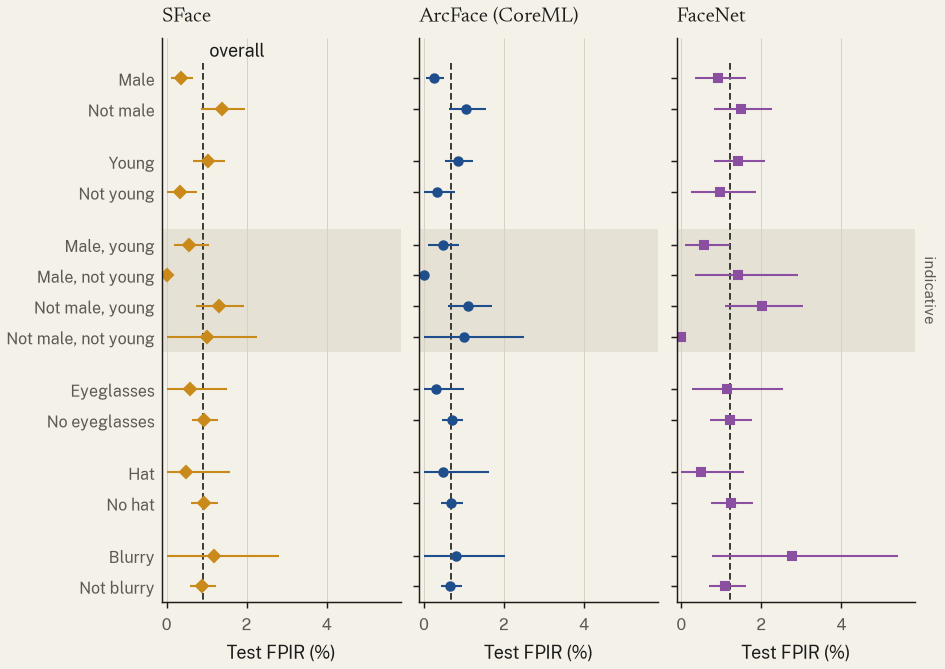

In [13]:
group_fpir(results)